In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [4]:
X,y = make_circles(n_samples=1000, noise=0.1,factor=0.5,random_state=42)

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
X_train,X_test,y_train,y_test = train_test_split(X_scaled,y,test_size=0.2,random_state=42)

In [9]:
def build_model():
    model = Sequential([
        Dense(16,input_shape=(2,),activation='relu'),
        Dense(8,activation='relu'),
        Dense(1,activation='sigmoid')])
    return model

In [10]:
model_adagrad = build_model()
model_adagrad.compile(optimizer=tf.keras.optimizers.Adagrad(learning_rate=0.01),loss='binary_crossentropy',metrics=['accuracy'])

model_rmsprop = build_model()
model_rmsprop.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.01),loss='binary_crossentropy',metrics=['accuracy'])

In [11]:
epochs=50
batch_size=32
print("training model with adagrad")
history_adagrad = model_adagrad.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=epochs,batch_size=batch_size,verbose=0)

print("training model with rmsprop")
history_rmsprop = model_rmsprop.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=epochs,batch_size=batch_size,verbose=0)

training model with adagrad
training model with rmsprop


In [12]:
loss_ada,acc_ada =model_adagrad.evaluate(X_test,y_test,verbose=0)
loss_rms,acc_rms =model_rmsprop.evaluate(X_test,y_test,verbose=0)
print(f"\nfinal adagrad test accuracy: {acc_ada*100:.2f}%")
print(f"\nfinal rmsprop test accuracy: {acc_rms*100:.2f}%")


final adagrad test accuracy: 96.50%

final rmsprop test accuracy: 96.50%


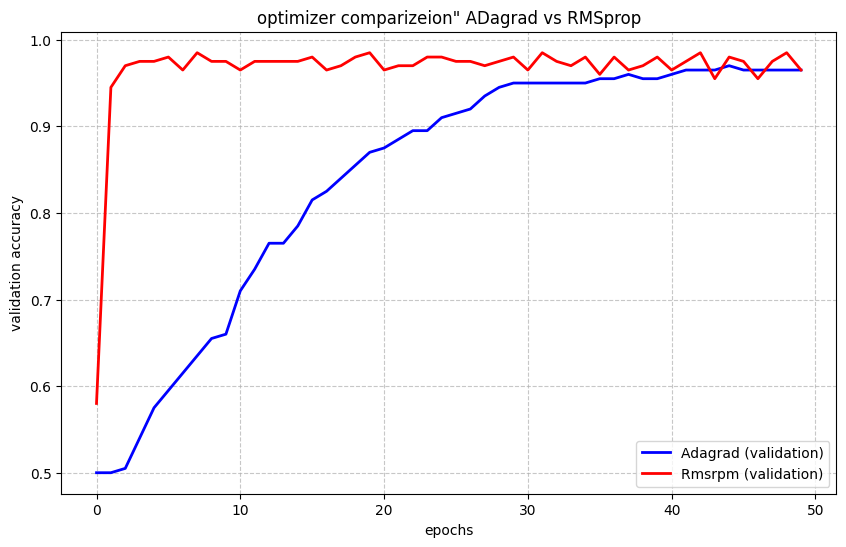

In [15]:
plt.figure(figsize=(10,6))
plt.plot(history_adagrad.history['val_accuracy'],label='Adagrad (validation)',color='blue',linewidth=2)
plt.plot(history_rmsprop.history['val_accuracy'],label='Rmsrpm (validation)',color='red',linewidth=2)
plt.title('optimizer comparizeion" ADagrad vs RMSprop')
plt.xlabel('epochs')
plt.ylabel('validation accuracy')
plt.legend(loc='lower right')
plt.grid(True,linestyle='--',alpha=0.7)
plt.show()